<font size="+3"><strong>House Price Prediction</strong></font>

# 1. Linear Regression/Ridge Regession

#### Goal

The goal of this project is to predict the sales price for each house. For each Id in the test set, I must predict the value of the SalePrice variable. I want to leverage this process on kaggle in doing mine [House Price Prediction using Tensor Flow Decision Forest](https://www.kaggle.com/code/gusthema/house-prices-prediction-using-tfdf/notebook), though I won't be using Tensor Flow. 

Information on this project is here [House Price Prediction](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview)

## Import Libraries

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from category_encoders import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

warnings.simplefilter(action="ignore")

## Import Data

Load data to see the firt 5 rows and also data info

In [164]:
df = pd.read_csv("Desktop/Data Set Project Practice/house-prices-advanced-regression-techniques/train.csv")

In [165]:
pd.set_option("display.max_columns", None)
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Data Exploration and Feature Engineering

So First we can see that there are some columns like "Alley", "PoolQC" etc with outrageous nulls, I will drop them

In [169]:
#Drop Columns with Outrageous nulls
df.drop(columns=["Alley","MasVnrType","FireplaceQu","PoolQC","Fence","MiscFeature"], inplace=True)
print(df.shape)
df.head()

(1460, 75)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


I can't make use of the columns "YrSold", "YearBuilt" etc because they are in years. So I will be creating three new features `"HouseAge"`, `"RemodelAge"`, `"GarageAge"`. And also clean the column `"GarageAge"`.

In [171]:
# Extract "HouseAge", "RemodelAge" and "GarageAge"
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]

# Replace the NAN values in "GarageAge" with 0 and convert to int datatype
df["GarageAge"] = df["GarageAge"].fillna(0).astype(int)
df["GarageAge"].tail()

1455     8
1456    32
1457    69
1458    60
1459    43
Name: GarageAge, dtype: int32

Drop the columns `"YrSold"`, `"YearBuilt"`, `"YearRemodAdd"`, `"GarageYrBlt"` since they are no longer needed.

In [173]:
# Drop the columns "YrSold", "YearBuilt", "YearRemodAdd", "GarageYrBlt"
df.drop(columns=["YrSold", "YearBuilt", "YearRemodAdd", "GarageYrBlt"],inplace=True)
print(df.shape)
df.head()

(1460, 74)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodelAge,GarageAge
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,WD,Normal,208500,5,5,5
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,WD,Normal,181500,31,31,31
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,WD,Normal,223500,7,6,7
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,WD,Abnorml,140000,91,36,8
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,WD,Normal,250000,8,8,8


Convert the "Id" column from integer to string datatype.

In [175]:
# Convert the "Id" column from integer to string datatype.
df["Id"] = df["Id"].astype(str)
df["Id"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: Id
Non-Null Count  Dtype 
--------------  ----- 
1460 non-null   object
dtypes: object(1)
memory usage: 11.5+ KB


Let's Check for high Cardinality features in the string datatype

In [177]:
df.select_dtypes("object").nunique()

Id               1460
MSZoning            5
Street              2
LotShape            4
LandContour         4
Utilities           2
LotConfig           5
LandSlope           3
Neighborhood       25
Condition1          9
Condition2          8
BldgType            5
HouseStyle          8
RoofStyle           6
RoofMatl            8
Exterior1st        15
Exterior2nd        16
ExterQual           4
ExterCond           5
Foundation          6
BsmtQual            4
BsmtCond            4
BsmtExposure        4
BsmtFinType1        6
BsmtFinType2        6
Heating             6
HeatingQC           5
CentralAir          2
Electrical          5
KitchenQual         4
Functional          7
GarageType          6
GarageFinish        3
GarageQual          5
GarageCond          5
PavedDrive          3
SaleType            9
SaleCondition       6
dtype: int64

So the only high cardinality feature is the "Id" column and we will drop this before training the data

Now Let's select features that are numerical in order to check for multicollinearity.

In [180]:
print(df.select_dtypes("number").shape)
df.select_dtypes("number").head()

(1460, 36)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SalePrice,HouseAge,RemodelAge,GarageAge
0,60,65.0,8450,7,5,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,208500,5,5,5
1,20,80.0,9600,6,8,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,181500,31,31,31
2,60,68.0,11250,7,5,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2,608,0,42,0,0,0,0,0,9,223500,7,6,7
3,70,60.0,9550,7,5,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,3,642,0,35,272,0,0,0,0,2,140000,91,36,8
4,60,84.0,14260,8,5,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,3,836,192,84,0,0,0,0,0,12,250000,8,8,8


Create a correlation heatmap to see features that are highly correlated with others.

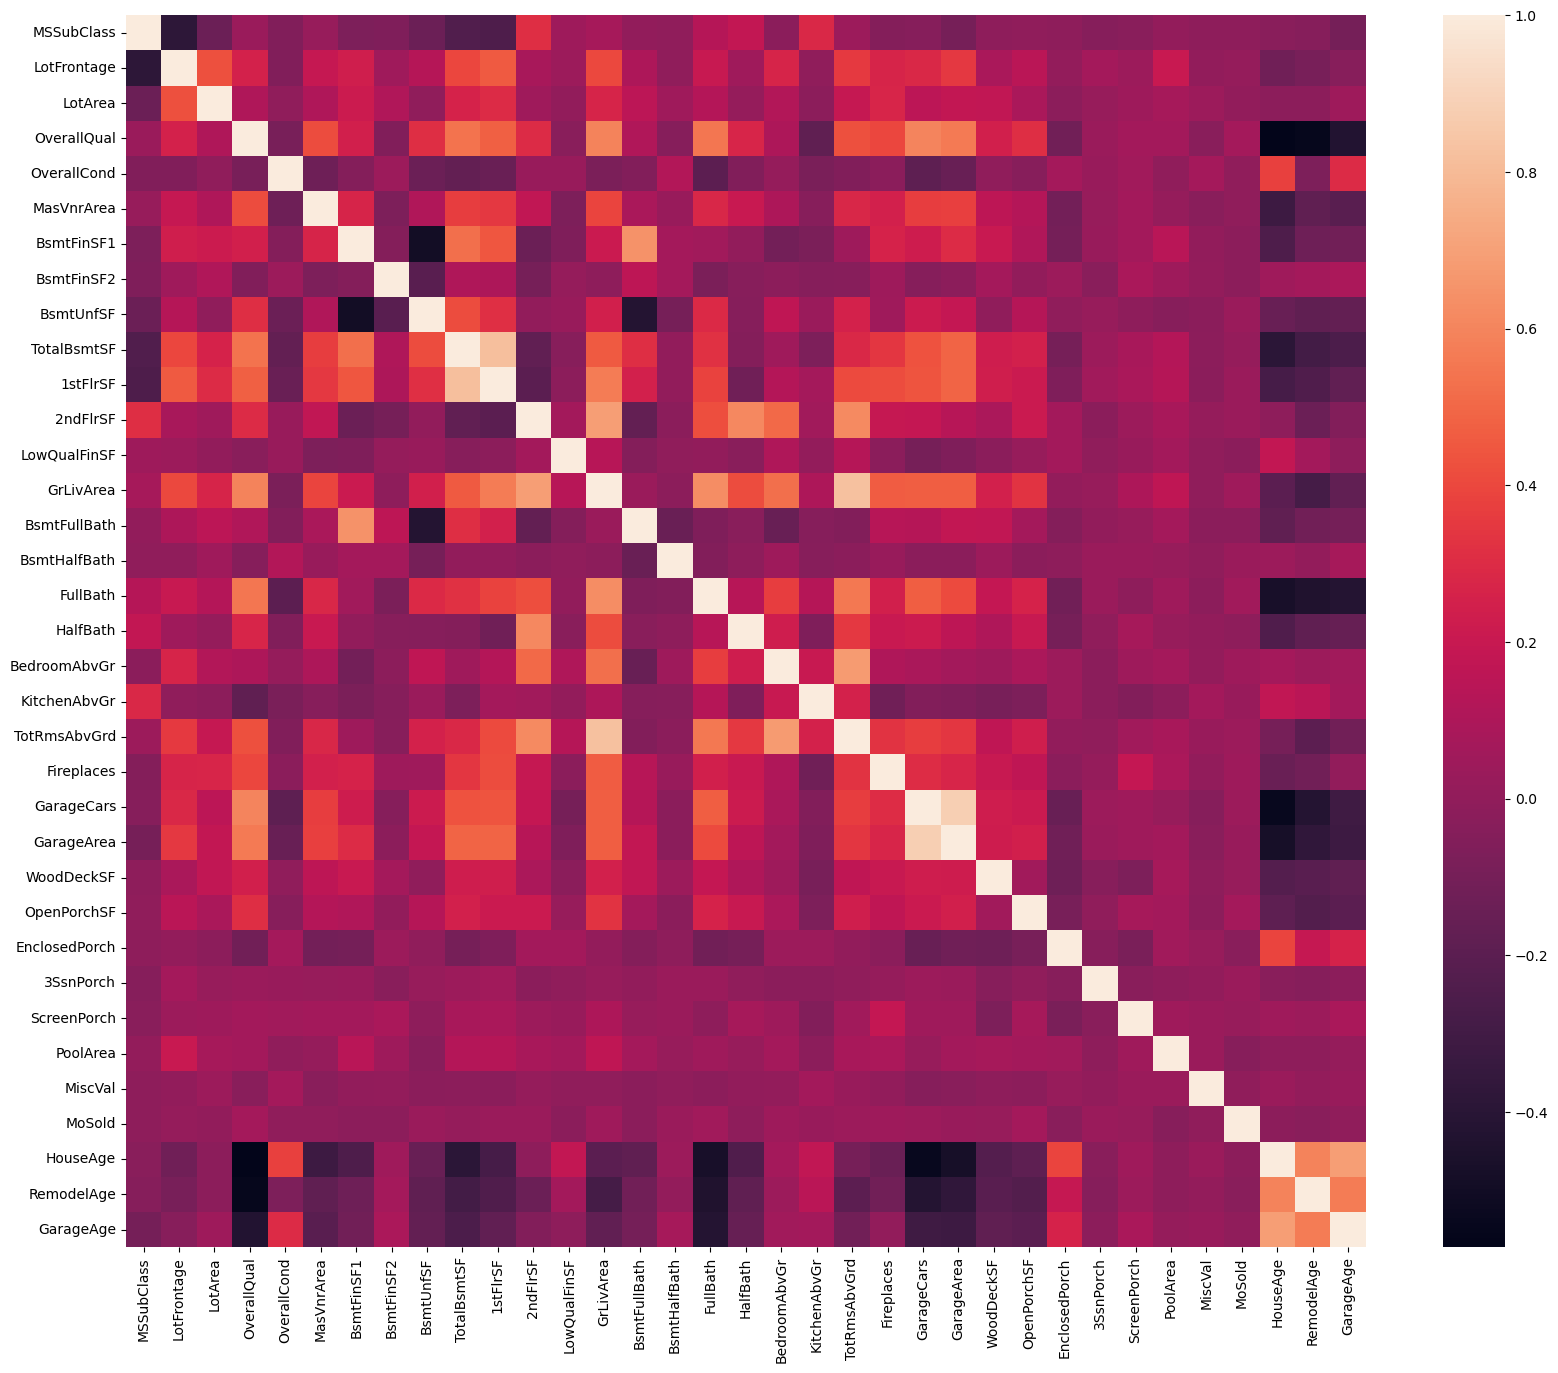

In [182]:
# Create a correlation heatmap to see features that are highly correlated with others.
correlation = df.select_dtypes("number").drop(columns="SalePrice").corr()
plt.figure(figsize=(20,16))
sns.heatmap(correlation)
plt.show();

The lighter orange colors from the heatmap shows features that are highly correlated with others. So from the heatmap above, I have selected the following features that are highly collinear `"TotalBsmtSF"`, `"1stFlrSF"`, `"GarageCars"`, `"GarageArea"`, `"TotRmsAbvGrd"`, `"GrLivArea"`. So I would likely be droping some of them.

In [184]:
 df[["TotalBsmtSF","1stFlrSF","GarageCars","GarageArea","TotRmsAbvGrd","GrLivArea"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   TotalBsmtSF   1460 non-null   int64
 1   1stFlrSF      1460 non-null   int64
 2   GarageCars    1460 non-null   int64
 3   GarageArea    1460 non-null   int64
 4   TotRmsAbvGrd  1460 non-null   int64
 5   GrLivArea     1460 non-null   int64
dtypes: int64(6)
memory usage: 68.6 KB


All the columns have no NAN values. But let's also see if they have zero values.

In [186]:
print((df["TotalBsmtSF"] == 0).value_counts())
print((df["1stFlrSF"] == 0).value_counts())
print((df["GarageCars"] == 0).value_counts())
print((df["GarageArea"] == 0).value_counts())
print((df["TotRmsAbvGrd"] == 0).value_counts())
print((df["GrLivArea"] == 0).value_counts())

TotalBsmtSF
False    1423
True       37
Name: count, dtype: int64
1stFlrSF
False    1460
Name: count, dtype: int64
GarageCars
False    1379
True       81
Name: count, dtype: int64
GarageArea
False    1379
True       81
Name: count, dtype: int64
TotRmsAbvGrd
False    1460
Name: count, dtype: int64
GrLivArea
False    1460
Name: count, dtype: int64


The columns `"TotalBsmtSF"` and `"1stFlrSF"` are highly correlated with each other, but since `"1stFlrSF"` has more none zero data, I will drop `"TotalBsmtSF"`

The columns `"GarageCars"` and `"GarageArea"` are also highly correlated with each other. They both have equal number of zero data, which is 81. But here, `"GarageCars"` refers to **"Size of garage in car capacity"**, while `"GarageArea"` refers to **"Size of garage in square feet"**. To me `"GarageArea"` is more relatable and interpretable, so I would drop `"GarageCars"`

`"TotRmsAbvGrd"` (**Total rooms above ground**) and `"GrLivArea"` (**Above ground living area in square feet**) are also highly correlated. To get a better interpretable feature and also to deal with multicollinearity, I will use both columns to generate a new column `"AvgRoomSize"` (**Average Room Size**). After this, I will drop these two columns (`"TotRmsAbvGrd"` and `"GrLivArea"`).

In [188]:
# drop Multicollinearity columns 
df["AvgRoomSize"] = (df["GrLivArea"] / df["TotRmsAbvGrd"]).round(1)
df.drop(columns=["TotalBsmtSF", "GarageCars", "TotRmsAbvGrd", "GrLivArea"], inplace=True)
print(df.shape)
df.head()

(1460, 71)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodelAge,GarageAge,AvgRoomSize
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,GasA,Ex,Y,SBrkr,856,854,0,1,0,2,1,3,1,Gd,Typ,0,Attchd,RFn,548,TA,TA,Y,0,61,0,0,0,0,0,2,WD,Normal,208500,5,5,5,213.8
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,GasA,Ex,Y,SBrkr,1262,0,0,0,1,2,0,3,1,TA,Typ,1,Attchd,RFn,460,TA,TA,Y,298,0,0,0,0,0,0,5,WD,Normal,181500,31,31,31,210.3
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,GasA,Ex,Y,SBrkr,920,866,0,1,0,2,1,3,1,Gd,Typ,1,Attchd,RFn,608,TA,TA,Y,0,42,0,0,0,0,0,9,WD,Normal,223500,7,6,7,297.7
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,GasA,Gd,Y,SBrkr,961,756,0,1,0,1,0,3,1,Gd,Typ,1,Detchd,Unf,642,TA,TA,Y,0,35,272,0,0,0,0,2,WD,Abnorml,140000,91,36,8,245.3
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,GasA,Ex,Y,SBrkr,1145,1053,0,1,0,2,1,4,1,Gd,Typ,1,Attchd,RFn,836,TA,TA,Y,192,84,0,0,0,0,0,12,WD,Normal,250000,8,8,8,244.2


Now we have to set the "Id" column to index, so it doesn't interfer with training by causing high cardinality or leakages.

In [190]:
# Set the "Id" column to idex.
df = df.set_index("Id")
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodelAge,GarageAge,AvgRoomSize
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,GasA,Ex,Y,SBrkr,856,854,0,1,0,2,1,3,1,Gd,Typ,0,Attchd,RFn,548,TA,TA,Y,0,61,0,0,0,0,0,2,WD,Normal,208500,5,5,5,213.8
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,GasA,Ex,Y,SBrkr,1262,0,0,0,1,2,0,3,1,TA,Typ,1,Attchd,RFn,460,TA,TA,Y,298,0,0,0,0,0,0,5,WD,Normal,181500,31,31,31,210.3
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,GasA,Ex,Y,SBrkr,920,866,0,1,0,2,1,3,1,Gd,Typ,1,Attchd,RFn,608,TA,TA,Y,0,42,0,0,0,0,0,9,WD,Normal,223500,7,6,7,297.7
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,GasA,Gd,Y,SBrkr,961,756,0,1,0,1,0,3,1,Gd,Typ,1,Detchd,Unf,642,TA,TA,Y,0,35,272,0,0,0,0,2,WD,Abnorml,140000,91,36,8,245.3
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,GasA,Ex,Y,SBrkr,1145,1053,0,1,0,2,1,4,1,Gd,Typ,1,Attchd,RFn,836,TA,TA,Y,192,84,0,0,0,0,0,12,WD,Normal,250000,8,8,8,244.2


## Descriptive Statistics

Looking at the descriptive statistics and distribution of our target "SalePrice", we have;

count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


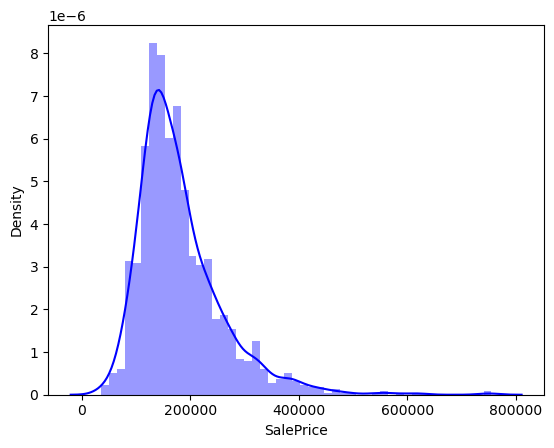

In [193]:
print(df["SalePrice"].describe().round(2))
sns.distplot(df["SalePrice"], color="b");

So our target "SalePrice" is positively skewed. Also a high standard deviation of 79,442.5, relative to the mean of 180,921.2 shows dispersion, hence we need to normalize the distribution of "SalePrice", by using a **Log Transformation** as this would help our linear/ridge regression model perform better. 

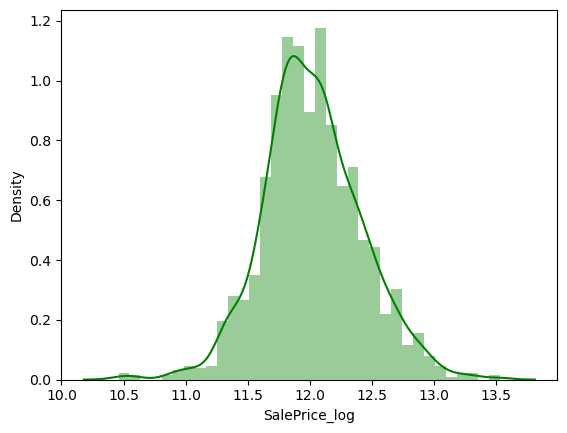

In [195]:
# Create a new column "SalePrice_log" to become the target
df["SalePrice_log"] = np.log1p(df["SalePrice"])
sns.distplot(df["SalePrice_log"], color="g");

Our target "SalePrice" is now a normal distribution. So our new target for training our model becomes `"SalePrice_log"`, but I will use `np.expm1()` to bring predictions back to original scale later. 

But let's look at the distribution of our features, we have 

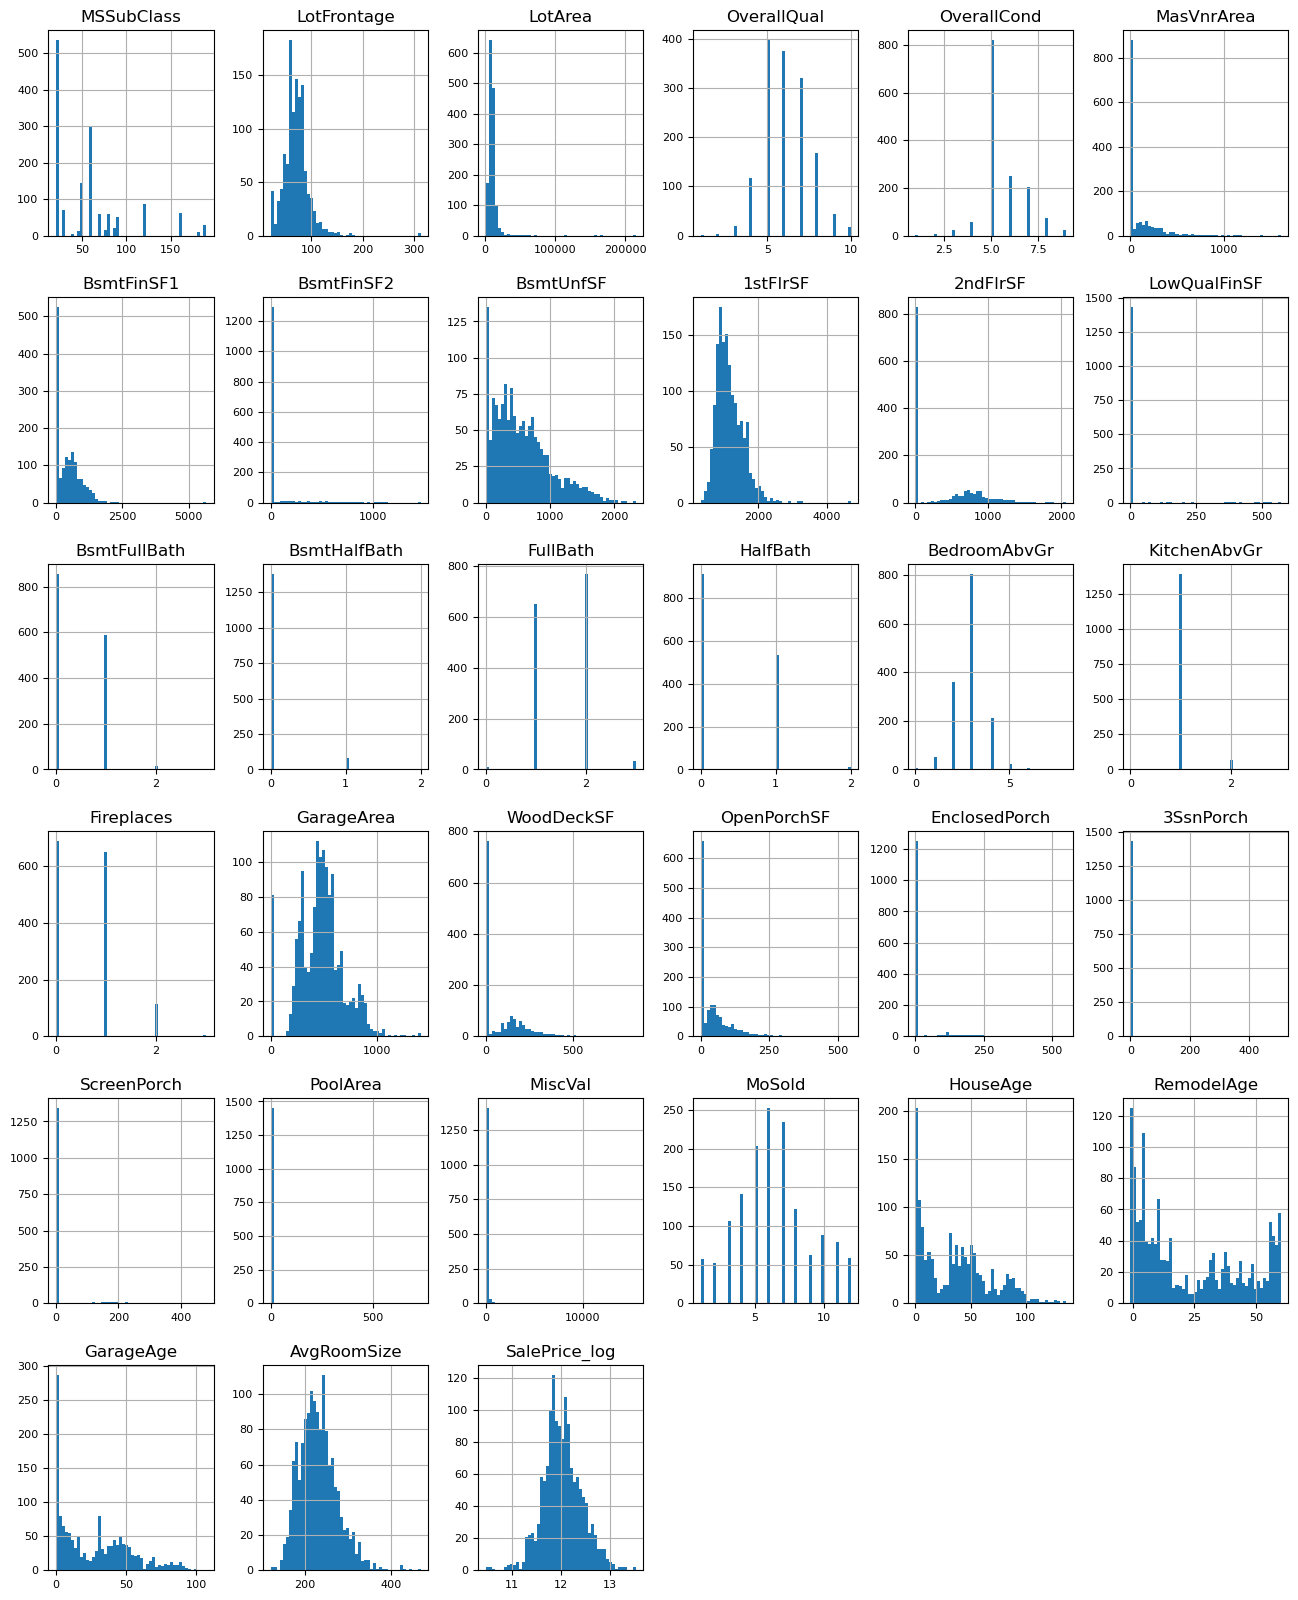

In [197]:
df.select_dtypes("number").drop(columns="SalePrice").hist(figsize=(16,20), bins=50, xlabelsize=8, ylabelsize=8);

Some of our features also have a positively skewed distribution. We will consider this during training our model.

### Function to Import and Clean Data

In [200]:
def wrangle(filepath):
    # Read data as a csv file
    df = pd.read_csv(filepath)

    #Drop Columns with Outrageous nulls
    df.drop(columns=["Alley","MasVnrType","FireplaceQu","PoolQC","Fence","MiscFeature"], inplace=True)

    # Extract "HouseAge", "RemodelAge" and "GarageAge"
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]
    
    # Replace the NAN values in "GarageAge" with 0 and convert to int datatype
    df["GarageAge"] = df["GarageAge"].fillna(0).astype(int)
    
    # Drop the columns "YrSold", "YearBuilt", "YearRemodAdd", "GarageYrBlt"
    df.drop(columns=["YrSold", "YearBuilt", "YearRemodAdd", "GarageYrBlt"],inplace=True)

    # Convert the "Id" column from integer to string datatype.
    df["Id"] = df["Id"].astype(str)

    # drop Multicollinearity columns 
    df["AvgRoomSize"] = (df["GrLivArea"] / df["TotRmsAbvGrd"]).round(1)
    df.drop(columns=["TotalBsmtSF", "GarageCars", "TotRmsAbvGrd", "GrLivArea"], inplace=True)

    # Set the "Id" column to idex.
    df = df.set_index("Id")
    
    return df

In [201]:
df = wrangle("Desktop/Data Set Project Practice/house-prices-advanced-regression-techniques/train.csv")
print(df.shape)
df.head()

(1460, 70)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodelAge,GarageAge,AvgRoomSize
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,GasA,Ex,Y,SBrkr,856,854,0,1,0,2,1,3,1,Gd,Typ,0,Attchd,RFn,548,TA,TA,Y,0,61,0,0,0,0,0,2,WD,Normal,208500,5,5,5,213.8
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,GasA,Ex,Y,SBrkr,1262,0,0,0,1,2,0,3,1,TA,Typ,1,Attchd,RFn,460,TA,TA,Y,298,0,0,0,0,0,0,5,WD,Normal,181500,31,31,31,210.3
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,GasA,Ex,Y,SBrkr,920,866,0,1,0,2,1,3,1,Gd,Typ,1,Attchd,RFn,608,TA,TA,Y,0,42,0,0,0,0,0,9,WD,Normal,223500,7,6,7,297.7
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,GasA,Gd,Y,SBrkr,961,756,0,1,0,1,0,3,1,Gd,Typ,1,Detchd,Unf,642,TA,TA,Y,0,35,272,0,0,0,0,2,WD,Abnorml,140000,91,36,8,245.3
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,GasA,Ex,Y,SBrkr,1145,1053,0,1,0,2,1,4,1,Gd,Typ,1,Attchd,RFn,836,TA,TA,Y,192,84,0,0,0,0,0,12,WD,Normal,250000,8,8,8,244.2


In [202]:
# Create a new column "SalePrice_log" to become the target
df["SalePrice_log"] = np.log1p(df["SalePrice"])
print(df.shape)
df.head()

(1460, 71)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodelAge,GarageAge,AvgRoomSize,SalePrice_log
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,GasA,Ex,Y,SBrkr,856,854,0,1,0,2,1,3,1,Gd,Typ,0,Attchd,RFn,548,TA,TA,Y,0,61,0,0,0,0,0,2,WD,Normal,208500,5,5,5,213.8,12.247699
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,GasA,Ex,Y,SBrkr,1262,0,0,0,1,2,0,3,1,TA,Typ,1,Attchd,RFn,460,TA,TA,Y,298,0,0,0,0,0,0,5,WD,Normal,181500,31,31,31,210.3,12.109016
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,GasA,Ex,Y,SBrkr,920,866,0,1,0,2,1,3,1,Gd,Typ,1,Attchd,RFn,608,TA,TA,Y,0,42,0,0,0,0,0,9,WD,Normal,223500,7,6,7,297.7,12.317171
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,GasA,Gd,Y,SBrkr,961,756,0,1,0,1,0,3,1,Gd,Typ,1,Detchd,Unf,642,TA,TA,Y,0,35,272,0,0,0,0,2,WD,Abnorml,140000,91,36,8,245.3,11.849405
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,GasA,Ex,Y,SBrkr,1145,1053,0,1,0,2,1,4,1,Gd,Typ,1,Attchd,RFn,836,TA,TA,Y,192,84,0,0,0,0,0,12,WD,Normal,250000,8,8,8,244.2,12.429220


## Split

So we will be doing both vertical and horizontal split. That is splitting our data into a `Feature matrix` and a `Target vector`, and also, into a `Training set` and a `Validation set`.

In [205]:
# Create feature matrix and target vector
target = "SalePrice_log"
y = df[target]
X = df.drop(columns=[target, "SalePrice"])

# Save "Id" column separately
Id = df.index

print(y.shape)
print(y.head())
print(X.shape)
X.head()

(1460,)
Id
1    12.247699
2    12.109016
3    12.317171
4    11.849405
5    12.429220
Name: SalePrice_log, dtype: float64
(1460, 69)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,HouseAge,RemodelAge,GarageAge,AvgRoomSize
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,GasA,Ex,Y,SBrkr,856,854,0,1,0,2,1,3,1,Gd,Typ,0,Attchd,RFn,548,TA,TA,Y,0,61,0,0,0,0,0,2,WD,Normal,5,5,5,213.8
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,GasA,Ex,Y,SBrkr,1262,0,0,0,1,2,0,3,1,TA,Typ,1,Attchd,RFn,460,TA,TA,Y,298,0,0,0,0,0,0,5,WD,Normal,31,31,31,210.3
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,GasA,Ex,Y,SBrkr,920,866,0,1,0,2,1,3,1,Gd,Typ,1,Attchd,RFn,608,TA,TA,Y,0,42,0,0,0,0,0,9,WD,Normal,7,6,7,297.7
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,GasA,Gd,Y,SBrkr,961,756,0,1,0,1,0,3,1,Gd,Typ,1,Detchd,Unf,642,TA,TA,Y,0,35,272,0,0,0,0,2,WD,Abnorml,91,36,8,245.3
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,GasA,Ex,Y,SBrkr,1145,1053,0,1,0,2,1,4,1,Gd,Typ,1,Attchd,RFn,836,TA,TA,Y,192,84,0,0,0,0,0,12,WD,Normal,8,8,8,244.2


In [206]:
# Split data into training and Validation sets
X_train, X_val, y_train, y_val, Id_train, Id_val = train_test_split(
    X, y, Id, test_size=0.2, random_state=42
)
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_val Shape:", X_val.shape)
print("y_val Shape", y_val.shape)
print("Id_train Shape", Id_train.shape)
print("Id_val Shape", Id_val.shape)

X_train Shape: (1168, 69)
y_train Shape: (1168,)
X_val Shape: (292, 69)
y_val Shape (292,)
Id_train Shape (1168,)
Id_val Shape (292,)


## Build Model

### Baseline

Now I will build the Baseline Mean absolute error for my model

In [210]:
# Build Baseline Mean Absolute Error for model
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
print("MAE Baseline:", mae_baseline)

MAE Baseline: 0.3033671860808526


### Iterate

I will now build a model and fit it to the training data, using both Linear and Ridge Regression, and calculate the mean absolute error of both models

In [213]:
# Build model on Ridge Regression
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(strategy="median"),
    Ridge()
)
# fit model to the training data
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['MSZoning', 'Street', 'LotShape',
                                     'LandContour', 'Utilities', 'LotConfig',
                                     'LandSlope', 'Neighborhood', 'Condition1',
                                     'Condition2', 'BldgType', 'HouseStyle',
                                     'RoofStyle', 'RoofMatl', 'Exterior1st',
                                     'Exterior2nd', 'ExterQual', 'ExterCond',
                                     'Foundation', 'BsmtQual', 'BsmtCond',
                                     'BsmtExposure', 'BsmtFinType1',
                                     'BsmtFinType2', 'Heating', 'HeatingQC',
                                     'CentralAir', 'Electrical', 'KitchenQual',
                                     'Functional', ...],
                               use_cat_names=True)),
                ('simpleimputer', SimpleImputer(strategy='median')),
                ('ridge', Ridge())])

In [214]:
# calculate MAE of Ridge regression model
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("MAE of Ridge Regression Model:", round(mae_training, 3))

MAE of Ridge Regression Model: 0.07


In [215]:
# Build Model on Linear Regression
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(strategy="median"),
    LinearRegression()
)
# Fit model to the training data
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['MSZoning', 'Street', 'LotShape',
                                     'LandContour', 'Utilities', 'LotConfig',
                                     'LandSlope', 'Neighborhood', 'Condition1',
                                     'Condition2', 'BldgType', 'HouseStyle',
                                     'RoofStyle', 'RoofMatl', 'Exterior1st',
                                     'Exterior2nd', 'ExterQual', 'ExterCond',
                                     'Foundation', 'BsmtQual', 'BsmtCond',
                                     'BsmtExposure', 'BsmtFinType1',
                                     'BsmtFinType2', 'Heating', 'HeatingQC',
                                     'CentralAir', 'Electrical', 'KitchenQual',
                                     'Functional', ...],
                               use_cat_names=True)),
                ('simpleimputer', SimpleImputer(strategy='median')),
                ('linearregression', LinearRegression())])

In [216]:
# Calculate MAE of Linear Regression model
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("MAE of Linear Regression Model:", round(mae_training, 4))

MAE of Linear Regression Model: 0.064


So both models MAE beat the Baseline, and since the lower the MAE, the better the model performance in detecting patterns, hence I will go for the Linear Model, since it's MAE is lower **0.064**, as compared to the Ridge MAE of **0.07**

### Evaluate

Now let's test our model to see how it performs on the Validation set

In [220]:
y_pred_val = model.predict(X_val)
mae_validation = mean_absolute_error(y_val, y_pred_val)
print("MAE of Validation", mae_validation)
print(np.expm1(y_pred_val[:5]).round(2))

MAE of Validation 0.08974487031899302
[152869.46 341442.2   97817.84 163209.65 315384.02]


Our Validation MAE is 0.08974. So our Linear Regression model performed slightly better in the training set (0.064) than the validation set. But since our Validation MAE beats the Baseline MAE (0.3034), then our model is still good to go with. 

### Communication

Now that we have a working model, let's look at the feature importances of our model. That is the features that have the greatest predictive power to our model, or the features our model rely on most in making its predictions.

In [224]:
#Extract the feature names of the encoded data from OneHotEncoder in model.
feature_name = model.named_steps["onehotencoder"].get_feature_names()
print("feature counts:", len(feature_name))
print(feature_name[:20]) # first five features

feature counts: 270
['MSSubClass' 'MSZoning_RL' 'MSZoning_RM' 'MSZoning_FV' 'MSZoning_RH'
 'MSZoning_C (all)' 'LotFrontage' 'LotArea' 'Street_Pave' 'Street_Grvl'
 'LotShape_Reg' 'LotShape_IR1' 'LotShape_IR2' 'LotShape_IR3'
 'LandContour_Lvl' 'LandContour_Bnk' 'LandContour_HLS' 'LandContour_Low'
 'Utilities_AllPub' 'Utilities_NoSeWa']


Next I will create the intercept and coefficients of my model with the features that I have extracted

In [226]:
intercept = model.named_steps["linearregression"].intercept_
coefficient = model.named_steps["linearregression"].coef_
print("coefficient count:", len(coefficient))
print(np.expm1(coefficient[:10]))
print(np.expm1(intercept))

coefficient count: 270
[-4.69496129e-04  6.46703533e-02  3.53079638e-02  9.16599949e-02
  9.40526340e-02 -2.40391750e-01  2.28404382e-04  2.13811943e-06
  2.32086615e-02 -2.26822371e-02]
26589.04904450334


Next I will creat a pandas Series named feat_imp where the index is my features and the values are your coefficients

In [228]:
feat_imp = pd.Series(coefficient, index=feature_name)
feat_imp

MSSubClass              -0.000470
MSZoning_RL              0.062665
MSZoning_RM              0.034699
MSZoning_FV              0.087699
MSZoning_RH              0.089889
                           ...   
SaleCondition_AdjLand    0.016986
HouseAge                -0.001904
RemodelAge              -0.001151
GarageAge                0.000294
AvgRoomSize              0.000188
Length: 270, dtype: float64

I will now creat a horizontal bar chart that shows the top 20 coefficients for my model, based on their absolute value.

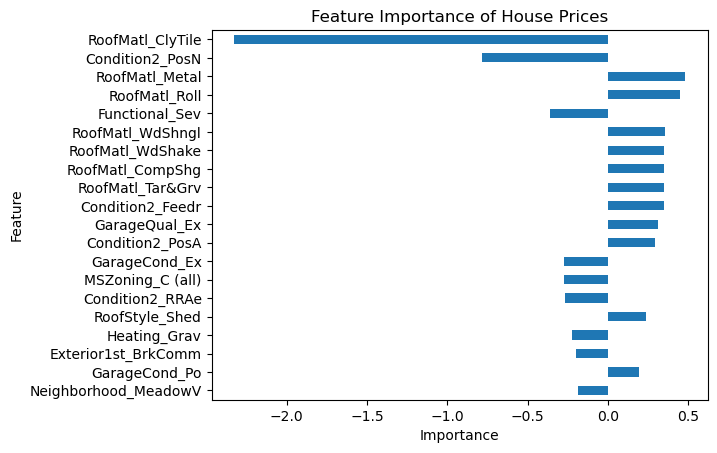

In [230]:
feat_imp.sort_values(key=abs).tail(20).plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance of House Prices");

The features above have the highest pridictive power of the model. If the value of the Features with negative coefficients increases, then the price for the house would decrease. And also, if the features with positive coefficients are increased in value, then the price for the house would increase. 

Next I will have to create an equation for my Multidimentionality Model which has many Features.

In [233]:
print(f"'House Price' = {np.expm1(intercept).round(2)}")
for f, c in feat_imp.items():
    print(f" + {round(c,4)} * {f})")

'House Price' = 26589.05
 + -0.0005 * MSSubClass)
 + 0.0627 * MSZoning_RL)
 + 0.0347 * MSZoning_RM)
 + 0.0877 * MSZoning_FV)
 + 0.0899 * MSZoning_RH)
 + -0.275 * MSZoning_C (all))
 + 0.0002 * LotFrontage)
 + 0.0 * LotArea)
 + 0.0229 * Street_Pave)
 + -0.0229 * Street_Grvl)
 + -0.0104 * LotShape_Reg)
 + -0.0149 * LotShape_IR1)
 + 0.0153 * LotShape_IR2)
 + 0.0099 * LotShape_IR3)
 + 0.0102 * LandContour_Lvl)
 + -0.014 * LandContour_Bnk)
 + 0.0247 * LandContour_HLS)
 + -0.0209 * LandContour_Low)
 + 0.0924 * Utilities_AllPub)
 + -0.0924 * Utilities_NoSeWa)
 + 0.0204 * LotConfig_Inside)
 + 0.0325 * LotConfig_Corner)
 + 0.0631 * LotConfig_CulDSac)
 + -0.0073 * LotConfig_FR2)
 + -0.1086 * LotConfig_FR3)
 + 0.0499 * LandSlope_Gtl)
 + 0.0467 * LandSlope_Mod)
 + -0.0965 * LandSlope_Sev)
 + -0.0337 * Neighborhood_NAmes)
 + -0.0036 * Neighborhood_Gilbert)
 + -0.0618 * Neighborhood_Edwards)
 + 0.0192 * Neighborhood_SWISU)
 + -0.0138 * Neighborhood_CollgCr)
 + -0.0535 * Neighborhood_IDOTRR)
 + -0.034

### Predicting Sales Price for Test data

Finally, I will now load my test data into the wrangle function that I have created. So the function cleans my data and display a data which I will use to predict the house prices.

In [236]:
X_test = wrangle("Desktop/Data Set Project Practice/house-prices-advanced-regression-techniques/test.csv")
Id_test = X_test.index
print(X_test.shape)
X_test.head()

(1459, 69)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,GarageType,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,HouseAge,RemodelAge,GarageAge,AvgRoomSize
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,GasA,TA,Y,SBrkr,896,0,0,0.0,0.0,1,0,2,1,TA,Typ,0,Attchd,Unf,730.0,TA,TA,Y,140,0,0,0,120,0,0,6,WD,Normal,49,49,49,179.2
1462,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,Hip,CompShg,Wd Sdng,Wd Sdng,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,GasA,TA,Y,SBrkr,1329,0,0,0.0,0.0,1,1,3,1,Gd,Typ,0,Attchd,Unf,312.0,TA,TA,Y,393,36,0,0,0,0,12500,6,WD,Normal,52,52,52,221.5
1463,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,GasA,Gd,Y,SBrkr,928,701,0,0.0,0.0,2,1,3,1,TA,Typ,1,Attchd,Fin,482.0,TA,TA,Y,212,34,0,0,0,0,0,3,WD,Normal,13,12,13,271.5
1464,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,Gable,CompShg,VinylSd,VinylSd,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,GasA,Ex,Y,SBrkr,926,678,0,0.0,0.0,2,1,3,1,Gd,Typ,1,Attchd,Fin,470.0,TA,TA,Y,360,36,0,0,0,0,0,6,WD,Normal,12,12,12,229.1
1465,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,Gable,CompShg,HdBoard,HdBoard,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,GasA,Ex,Y,SBrkr,1280,0,0,0.0,0.0,2,0,2,1,Gd,Typ,0,Attchd,RFn,506.0,TA,TA,Y,0,82,0,0,144,0,0,1,WD,Normal,18,18,18,256.0


Checking the first 5 predictions of my test set. 

In [238]:
y_test_pred = model.predict(X_test)
np.expm1(y_test_pred[:5]).round(2)

array([124404.95, 159374.07, 185308.83, 198271.16, 198550.83])

Displaying the predicted sales prices of all the houses in the test set, given the house Ids, I have below

In [240]:
result = pd.DataFrame(
    {
        "Id": Id_test,
        "Predicted SalePrice": np.expm1(y_test_pred).round(2)
    }
)
result.head(10)

,Id,Predicted SalePrice
0,1461,124404.95
1,1462,159374.07
2,1463,185308.83
3,1464,198271.16
4,1465,198550.83
5,1466,172388.43
6,1467,184919.05
7,1468,162228.74
8,1469,196726.46
9,1470,121241.50


Saving the House Ids and their Predicted Sales Prices as a csv, I have. 

In [88]:
# Save House Ids and predicted price as a csv file
result.to_csv("Predicted Prices For House.csv", index=False)